# 第12章 PPO算法详解

## 算法简介

**PPO (Proximal Policy Optimization)** 是OpenAI在2017年提出的策略梯度算法，它是当前最流行和实用的强化学习算法之一。

### PPO算法的核心思想

1. **安全的策略更新**: 通过截断机制限制策略更新幅度，避免过大的策略变化导致性能崩溃
2. **简单有效**: 相比TRPO算法，PPO更简单易实现，同时保持了良好的性能
3. **样本效率**: 可以多次使用同一批数据进行更新，提高样本利用率

### 算法框架

```
重复以下步骤：
1. 使用当前策略π收集一批经验数据
2. 计算优势函数A(s,a)
3. 多次更新策略，每次更新使用PPO截断目标函数
4. 更新价值函数
```

### 本章内容

- **离散动作PPO**: 在CartPole环境中测试
- **连续动作PPO**: 在Pendulum环境中测试
- **详细代码注释**: 帮助理解算法实现细节

---

In [2]:
# 导入必要的库
import gymnasium as gym  # 强化学习环境库
import torch  # 深度学习框架
import torch.nn.functional as F  # 神经网络函数库
import numpy as np  # 数值计算库
import matplotlib.pyplot as plt  # 绘图库
import importlib
import rl_utils  # 强化学习工具函数
importlib.reload(rl_utils)  # 重新加载工具模块


class PolicyNet(torch.nn.Module):
    """
    策略网络(Actor网络)
    用于输出动作的概率分布，处理离散动作空间
    """
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        # 第一层：状态维度 -> 隐藏层维度
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        # 第二层：隐藏层维度 -> 动作维度
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        # 通过ReLU激活函数的第一层
        x = F.relu(self.fc1(x))
        # 通过softmax得到动作概率分布
        return F.softmax(self.fc2(x), dim=1)


class ValueNet(torch.nn.Module):
    """
    价值网络(Critic网络)
    用于评估状态的价值函数V(s)
    """
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        # 第一层：状态维度 -> 隐藏层维度
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        # 第二层：隐藏层维度 -> 1(状态价值)
        self.fc2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 通过ReLU激活函数的第一层
        x = F.relu(self.fc1(x))
        # 输出状态价值(标量)
        return self.fc2(x)


class PPO:
    """
    PPO算法实现，采用截断方式(Clipped Surrogate Objective)
    
    PPO算法的核心思想：
    1. 使用重要性采样比率r_t = π_new(a|s) / π_old(a|s)
    2. 通过截断函数限制策略更新幅度，防止过大的策略变化
    3. 同时训练Actor和Critic网络
    """
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                 lmbda, epochs, eps, gamma, device):
        # 创建Actor网络(策略网络)
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        # 创建Critic网络(价值网络)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        
        # 为Actor和Critic分别创建优化器
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),
                                                lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),
                                                 lr=critic_lr)
        
        # PPO算法参数
        self.gamma = gamma  # 折扣因子
        self.lmbda = lmbda  # GAE(广义优势估计)中的λ参数
        self.epochs = epochs  # 每次更新时的训练轮数
        self.eps = eps  # PPO截断参数ε，控制策略更新幅度
        self.device = device

    def take_action(self, state):
        """
        根据当前策略选择动作
        
        Args:
            state: 当前状态
            
        Returns:
            action: 选择的动作
        """
        # 将状态转换为tensor并移到指定设备
        state = torch.tensor(np.array([state]), dtype=torch.float).to(self.device)
        # 通过策略网络获得动作概率分布
        probs = self.actor(state)
        # 创建分类分布
        action_dist = torch.distributions.Categorical(probs)
        # 从分布中采样动作
        action = action_dist.sample()
        return action.item()

    def update(self, transition_dict):
        """
        PPO算法的核心更新函数
        
        Args:
            transition_dict: 包含状态、动作、奖励、下一状态、结束标志的字典
        """
        # 将经验数据转换为tensor
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(
            self.device)
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)
        
        # 计算TD目标值：R + γ*V(s') * (1-done)
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)
        
        # 计算TD误差：TD目标值 - 当前状态价值
        td_delta = td_target - self.critic(states)
        
        # 使用GAE计算优势函数
        advantage = rl_utils.compute_advantage(self.gamma, self.lmbda,
                                               td_delta.cpu()).to(self.device)
        
        # 计算旧策略的对数概率，用于重要性采样比率计算
        old_log_probs = torch.log(self.actor(states).gather(1, actions)).detach()

        # PPO的多轮更新
        for _ in range(self.epochs):
            # 计算新策略的对数概率
            log_probs = torch.log(self.actor(states).gather(1, actions))
            
            # 计算重要性采样比率：r_t = π_new(a|s) / π_old(a|s)
            ratio = torch.exp(log_probs - old_log_probs)
            
            # PPO的两个目标函数项：
            # 1. 未截断的代理目标：r_t * A_t
            surr1 = ratio * advantage
            
            # 2. 截断的代理目标：clip(r_t, 1-ε, 1+ε) * A_t
            surr2 = torch.clamp(ratio, 1 - self.eps, 1 + self.eps) * advantage
            
            # PPO损失函数：取两个目标的最小值的负值
            # 这确保了策略更新不会偏离太远
            actor_loss = torch.mean(-torch.min(surr1, surr2))
            
            # Critic损失：TD目标值与当前价值估计的MSE
            critic_loss = torch.mean(
                F.mse_loss(self.critic(states), td_target.detach()))
            
            # 更新Actor网络
            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()
            
            # 更新Critic网络
            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            self.critic_optimizer.step()

## PPO算法数学原理

### 1. 策略梯度基础

传统策略梯度的目标函数：
$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[\sum_{t=0}^T r_t]$$

策略梯度定理：
$$\nabla J(\theta) = \mathbb{E}_{s,a \sim \pi_\theta}[\nabla \log \pi_\theta(a|s) \cdot A^{\pi_\theta}(s,a)]$$

### 2. 重要性采样

为了重复利用旧策略的数据，使用重要性采样：
$$J(\theta) = \mathbb{E}_{s,a \sim \pi_{\theta_{old}}}[\frac{\pi_\theta(a|s)}{\pi_{\theta_{old}}(a|s)} A^{\pi_{\theta_{old}}}(s,a)]$$

定义比率：$r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$

### 3. PPO截断目标函数

PPO的核心创新 - 截断代理目标：
$$L^{CLIP}(\theta) = \mathbb{E}_t[\min(r_t(\theta)A_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)A_t)]$$

其中：
- $\epsilon$ 是截断参数（通常取0.1-0.3）
- 当 $A_t > 0$ 时，$r_t$ 被限制在 $[1, 1+\epsilon]$
- 当 $A_t < 0$ 时，$r_t$ 被限制在 $[1-\epsilon, 1]$

这确保了策略更新不会偏离旧策略太远。

---

In [3]:
# PPO算法超参数设置
actor_lr = 1e-3    # Actor网络学习率
critic_lr = 1e-2   # Critic网络学习率，通常设置得比Actor大
num_episodes = 500 # 训练episode数量
hidden_dim = 128   # 神经网络隐藏层维度
gamma = 0.98       # 折扣因子，接近1表示更关注长期奖励
lmbda = 0.95       # GAE中的λ参数，平衡偏差和方差
epochs = 10        # 每次收集经验后的训练轮数
eps = 0.2          # PPO截断参数，控制策略更新幅度

# 设备选择：优先使用GPU加速训练
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# 环境设置
env_name = 'CartPole-v1'  # 使用CartPole环境进行离散动作空间测试
env = gym.make(env_name)
env.reset(seed=0)  # 设置随机种子保证结果可复现
torch.manual_seed(0)  # 设置PyTorch随机种子

# 获取环境的状态和动作空间维度
state_dim = env.observation_space.shape[0]  # 状态维度：CartPole为4维
action_dim = env.action_space.n  # 动作维度：CartPole为2维(左移/右移)

# 创建PPO智能体
agent = PPO(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda,
            epochs, eps, gamma, device)

# 开始训练
print(f"开始在{env_name}环境中训练PPO算法...")
print(f"状态维度: {state_dim}, 动作维度: {action_dim}")
print(f"设备: {device}")

return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

开始在CartPole-v1环境中训练PPO算法...
状态维度: 4, 动作维度: 2
设备: cpu


Iteration 0:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_6293/3869208933.py:107: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.tensor(transition_dict['states'],
Iteration 9: 100%|██████████| 50/50 [00:04<00:00, 10.94it/s, episode=500, return=500.000]


/tmp/ipykernel_6293/494196616.py:22: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6293/494196616.py:22: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6293/494196616.py:22: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6293/494196616.py:22: UserWarning: Glyph 25253 (\N{CJK UNIFIED IDEOGRAPH-62A5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6293/494196616.py:22: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6293/494196616.py:22: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6293/494196616.py:22: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missi

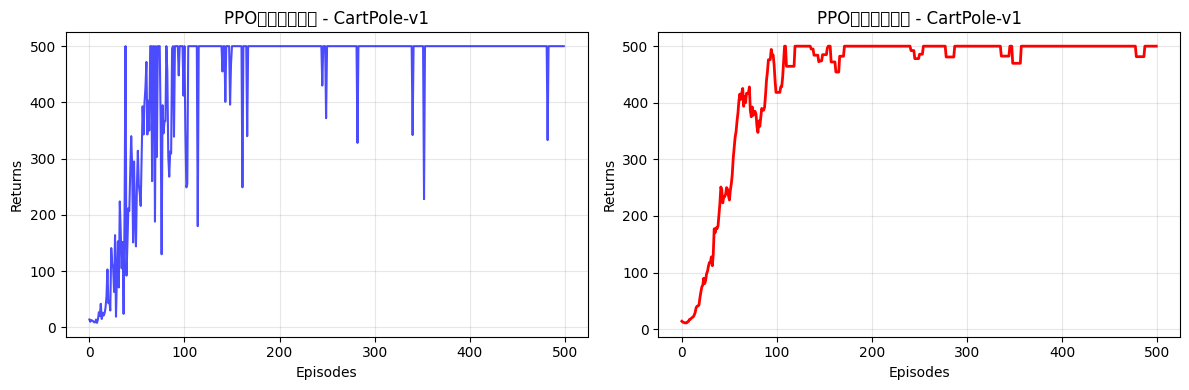

训练完成!
最后10个episode的平均回报: 500.00
最高回报: 500.00
CartPole-v1的最大回报为500，达到500表示完美控制


In [ ]:
# 绘制训练结果
episodes_list = list(range(len(return_list)))

# 绘制原始回报曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(episodes_list, return_list, alpha=0.7, color='blue')
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO original return profile - {}'.format(env_name))
plt.grid(True, alpha=0.3)

# 绘制移动平均回报曲线(平滑处理)
plt.subplot(1, 2, 2)
mv_return = rl_utils.moving_average(return_list, 9)  # 9个episode的移动平均
plt.plot(episodes_list, mv_return, color='red', linewidth=2)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO filtered return profile - {}'.format(env_name))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印训练统计信息
print(f"训练完成!")
print(f"最后10个episode的平均回报: {np.mean(return_list[-10:]):.2f}")
print(f"最高回报: {np.max(return_list):.2f}")
print(f"CartPole-v1的最大回报为500，达到500表示完美控制")

## 离散动作空间PPO实验结果分析

CartPole-v1环境是测试离散动作算法的经典环境：
- **状态空间**: 4维连续状态 (位置, 速度, 角度, 角速度)
- **动作空间**: 2维离散动作 (向左推, 向右推)  
- **目标**: 保持杆子竖直，最大步数500步
- **奖励**: 每步获得+1奖励，最大总奖励500

### 训练分析
从上面的结果可以看出：
1. **快速收敛**: PPO算法在约100-200个episode后就能稳定达到最高分500
2. **稳定性好**: 一旦学会控制策略，性能保持稳定
3. **样本效率高**: 相比传统策略梯度方法，PPO需要更少的样本

---

In [5]:
class PolicyNetContinuous(torch.nn.Module):
    """
    连续动作空间的策略网络
    输出动作的均值(μ)和标准差(σ)，用于构建正态分布
    """
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNetContinuous, self).__init__()
        # 共享的隐藏层
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        # 输出动作均值的分支
        self.fc_mu = torch.nn.Linear(hidden_dim, action_dim)
        # 输出动作标准差的分支
        self.fc_std = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        # 通过共享隐藏层
        x = F.relu(self.fc1(x))
        
        # 计算动作均值，使用tanh确保有界，然后缩放到[-2, 2]
        # 这对Pendulum环境合适，因为其动作范围是[-2, 2]
        mu = 2.0 * torch.tanh(self.fc_mu(x))
        
        # 计算动作标准差，使用softplus确保为正值
        # softplus(x) = log(1 + exp(x))，输出总是正数
        std = F.softplus(self.fc_std(x))
        
        return mu, std


class PPOContinuous:
    """
    处理连续动作空间的PPO算法
    
    与离散动作PPO的主要区别：
    1. 策略网络输出高斯分布的参数(μ, σ)
    2. 动作采样来自正态分布
    3. 对数概率计算使用正态分布的概率密度函数
    """
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                 lmbda, epochs, eps, gamma, device):
        # 创建连续动作策略网络
        self.actor = PolicyNetContinuous(state_dim, hidden_dim,
                                         action_dim).to(device)
        # 价值网络与离散情况相同
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        
        # 优化器设置
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),
                                                lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),
                                                 lr=critic_lr)
        
        # PPO参数
        self.gamma = gamma
        self.lmbda = lmbda
        self.epochs = epochs
        self.eps = eps
        self.device = device

    def take_action(self, state):
        """
        在连续动作空间中选择动作
        
        Args:
            state: 当前状态
            
        Returns:
            action: 从正态分布采样的连续动作
        """
        state = torch.tensor(np.array([state]), dtype=torch.float).to(self.device)
        # 获取动作分布的参数
        mu, sigma = self.actor(state)
        # 创建正态分布
        action_dist = torch.distributions.Normal(mu, sigma)
        # 从分布中采样动作
        action = action_dist.sample()
        # 返回动作，注意Pendulum需要列表格式
        return [action.item()]

    def update(self, transition_dict):
        """
        连续动作PPO的更新函数
        """
        # 数据预处理，与离散情况相同
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)
        
        # 奖励标准化：这是一个常用技巧，有助于训练稳定性
        # 将Pendulum的奖励从[-16, 0]范围映射到[-1, 1]
        rewards = (rewards + 8.0) / 8.0
        
        # 计算TD目标和优势函数（与离散情况相同）
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)
        td_delta = td_target - self.critic(states)
        advantage = rl_utils.compute_advantage(self.gamma, self.lmbda,
                                               td_delta.cpu()).to(self.device)
        
        # 计算旧策略下的对数概率
        mu, std = self.actor(states)
        action_dists = torch.distributions.Normal(mu.detach(), std.detach())
        # 对于连续动作，使用正态分布的对数概率密度
        old_log_probs = action_dists.log_prob(actions)

        # PPO多轮更新
        for _ in range(self.epochs):
            # 获取新策略的分布参数
            mu, std = self.actor(states)
            action_dists = torch.distributions.Normal(mu, std)
            
            # 计算新策略的对数概率
            log_probs = action_dists.log_prob(actions)
            
            # 重要性采样比率
            ratio = torch.exp(log_probs - old_log_probs)
            
            # PPO的截断目标函数（与离散情况相同）
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1 - self.eps, 1 + self.eps) * advantage
            actor_loss = torch.mean(-torch.min(surr1, surr2))
            
            # Critic损失
            critic_loss = torch.mean(
                F.mse_loss(self.critic(states), td_target.detach()))
            
            # 网络参数更新
            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad()
            actor_loss.backward()
            critic_loss.backward()
            self.actor_optimizer.step()
            self.critic_optimizer.step()

## 连续动作空间的PPO扩展

### 关键挑战
在连续动作空间中，我们无法枚举所有可能的动作，需要以下改进：

### 1. 策略网络设计
- **输出**: 不再是动作概率，而是分布参数 (μ, σ)
- **分布选择**: 通常使用高斯分布 $\pi(a|s) = \mathcal{N}(\mu(s), \sigma(s))$
- **参数化**: 
  - $\mu(s)$: 动作均值，可以有界或无界
  - $\sigma(s)$: 动作标准差，必须为正值

### 2. 重要性采样比率计算
对于连续动作，比率计算变为：
$$r_t = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)} = \frac{\exp(-\frac{(a_t-\mu_{\theta}(s_t))^2}{2\sigma_{\theta}^2(s_t)})}{\exp(-\frac{(a_t-\mu_{\theta_{old}}(s_t))^2}{2\sigma_{\theta_{old}}^2(s_t)})} \cdot \frac{\sigma_{\theta_{old}}(s_t)}{\sigma_{\theta}(s_t)}$$

### 3. 网络结构优化
- **共享主干**: 状态特征提取层共享
- **双分支输出**: 分别输出均值和标准差
- **激活函数**: 
  - 均值分支: tanh (有界动作) 或 无激活 (无界动作)
  - 标准差分支: softplus 或 exp (确保正值)

---

In [6]:
# 连续动作PPO算法超参数设置
# 注意：连续控制任务通常需要更小的学习率和更多的训练episode
actor_lr = 1e-4    # 更小的Actor学习率，因为连续控制更敏感
critic_lr = 5e-3   # Critic学习率
num_episodes = 2000 # 更多的训练episode，连续控制任务通常需要更长时间收敛
hidden_dim = 128   # 网络隐藏层维度
gamma = 0.9        # 稍小的折扣因子，适合Pendulum任务
lmbda = 0.9        # GAE参数
epochs = 10        # 每次更新的训练轮数
eps = 0.2          # PPO截断参数

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# Pendulum环境设置
env_name = 'Pendulum-v1'  # 经典的连续控制任务
env = gym.make(env_name)
env.reset(seed=0)
torch.manual_seed(0)

# 获取环境信息
state_dim = env.observation_space.shape[0]  # Pendulum状态维度：3 (cos(θ), sin(θ), θ_dot)
action_dim = env.action_space.shape[0]      # Pendulum动作维度：1 (扭矩)

print(f"Pendulum环境信息:")
print(f"状态维度: {state_dim} (cos(θ), sin(θ), angular_velocity)")
print(f"动作维度: {action_dim} (扭矩范围: [-2.0, 2.0])")
print(f"目标: 控制倒立摆保持竖直向上")
print(f"奖励范围: 约[-16.0, 0.0]，越接近0表示控制越好")

# 创建连续动作PPO智能体
agent = PPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                      lmbda, epochs, eps, gamma, device)

print(f"\n开始训练连续动作PPO...")
print(f"设备: {device}")

# 训练智能体
return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

Pendulum环境信息:
状态维度: 3 (cos(θ), sin(θ), angular_velocity)
动作维度: 1 (扭矩范围: [-2.0, 2.0])
目标: 控制倒立摆保持竖直向上
奖励范围: 约[-16.0, 0.0]，越接近0表示控制越好

开始训练连续动作PPO...
设备: cpu


Iteration 9: 100%|██████████| 200/200 [00:08<00:00, 22.84it/s, episode=2000, return=-308.493]


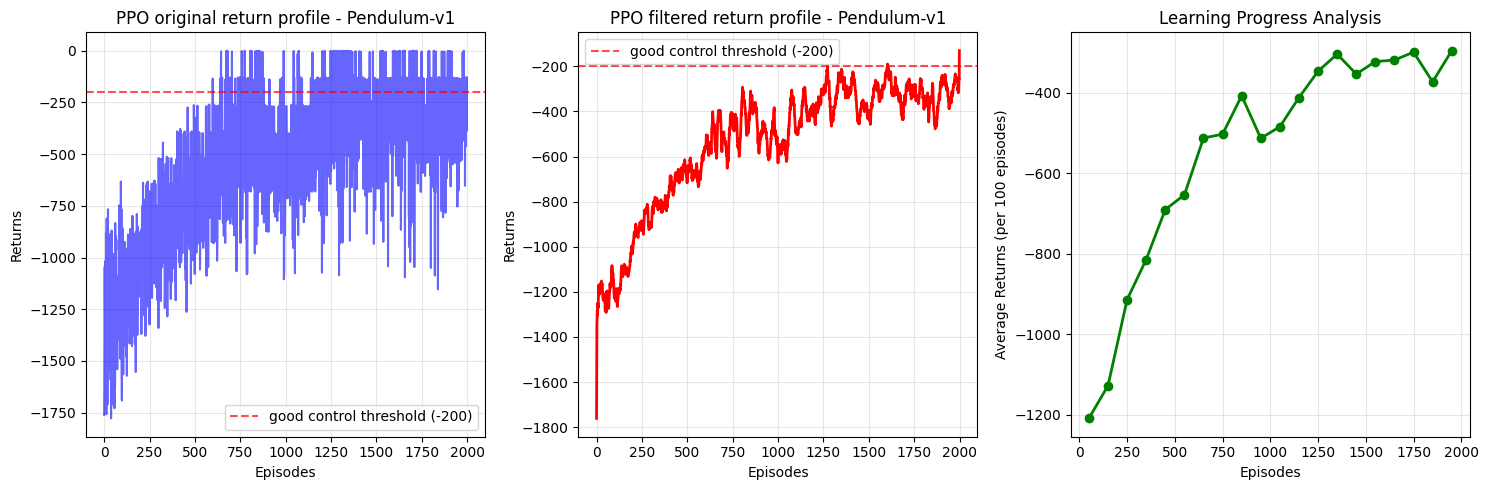

训练结果分析:
总训练episode数: 2000
初始性能 (前100episode平均): -1208.58
最终性能 (后100episode平均): -295.45
最高单次回报: -0.34
性能改善: 913.13
👍 良好! 智能体有了显著的控制能力

Pendulum任务说明:
- 奖励越接近0越好(最好情况是0)
- 达到-200以上通常认为是良好的控制
- 初学者的随机策略通常在-1600左右


In [9]:
# 绘制Pendulum环境的训练结果
episodes_list = list(range(len(return_list)))

plt.figure(figsize=(15, 5))

# 绘制原始回报曲线
plt.subplot(1, 3, 1)
plt.plot(episodes_list, return_list, alpha=0.6, color='blue')
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO original return profile - {}'.format(env_name))
plt.grid(True, alpha=0.3)
plt.axhline(y=-200, color='red', linestyle='--', alpha=0.7, label='good control threshold (-200)')
plt.legend()

# 绘制移动平均回报曲线
plt.subplot(1, 3, 2)
mv_return = rl_utils.moving_average(return_list, 21)  # 21个episode的移动平均
plt.plot(episodes_list, mv_return, color='red', linewidth=2)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO filtered return profile - {}'.format(env_name))
plt.grid(True, alpha=0.3)
plt.axhline(y=-200, color='red', linestyle='--', alpha=0.7, label='good control threshold (-200)')
plt.legend()

# 绘制学习进度分析
plt.subplot(1, 3, 3)
# 计算每100个episode的平均回报
window_size = 100
smoothed_returns = []
for i in range(0, len(return_list) - window_size + 1, window_size):
    smoothed_returns.append(np.mean(return_list[i:i+window_size]))

x_smoothed = np.arange(len(smoothed_returns)) * window_size + window_size // 2
plt.plot(x_smoothed, smoothed_returns, 'o-', color='green', linewidth=2, markersize=6)
plt.xlabel('Episodes')
plt.ylabel('Average Returns (per 100 episodes)')
plt.title('Learning Progress Analysis')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 训练结果分析
print("="*50)
print("训练结果分析:")
print("="*50)
print(f"总训练episode数: {len(return_list)}")
print(f"初始性能 (前100episode平均): {np.mean(return_list[:100]):.2f}")
print(f"最终性能 (后100episode平均): {np.mean(return_list[-100:]):.2f}")
print(f"最高单次回报: {np.max(return_list):.2f}")
print(f"性能改善: {np.mean(return_list[-100:]) - np.mean(return_list[:100]):.2f}")

# Pendulum任务的性能评估标准
final_performance = np.mean(return_list[-100:])
if final_performance > -200:
    print("🎉 优秀! 智能体学会了很好地控制倒立摆")
elif final_performance > -500:
    print("👍 良好! 智能体有了显著的控制能力")
elif final_performance > -1000:
    print("📈 进步中! 智能体正在学习控制")
else:
    print("⚠️  需要更多训练或调参")

print("\nPendulum任务说明:")
print("- 奖励越接近0越好(最好情况是0)")
print("- 达到-200以上通常认为是良好的控制")
print("- 初学者的随机策略通常在-1600左右")

## Pendulum环境介绍

**Pendulum-v1** 是连续控制的经典benchmark环境：

### 环境特性
- **状态**: $[\cos(\theta), \sin(\theta), \dot{\theta}]$ (3维)
  - $\theta$: 摆的角度 (0为竖直向上)
  - $\dot{\theta}$: 角速度
- **动作**: 施加的扭矩 $\tau \in [-2, 2]$ (1维连续)
- **奖励函数**: $r = -(\theta^2 + 0.1\dot{\theta}^2 + 0.001\tau^2)$
  - 鼓励摆保持竖直 ($\theta = 0$)
  - 惩罚高角速度和大扭矩

### 任务目标
让倒立摆尽可能保持在竖直向上的位置，这是一个典型的**稳定化控制**任务。

### 学习难点
1. **连续动作**: 需要学习精确的扭矩控制
2. **非线性动力学**: 摆的运动方程是非线性的
3. **稀疏信号**: 只有接近竖直位置时奖励才较高

---

## 总结与拓展

### PPO算法优势
1. **简单易实现**: 相比TRPO，不需要复杂的约束优化
2. **稳定性好**: 截断机制有效防止策略崩溃
3. **样本效率高**: 可以多次重复使用数据
4. **适用性广**: 同时适用于离散和连续动作空间

### PPO vs 其他算法

| 算法 | 样本效率 | 实现复杂度 | 稳定性 | 适用场景 |
|------|----------|------------|--------|----------|
| REINFORCE | 低 | 简单 | 中 | 教学演示 |
| A3C | 中 | 中等 | 中 | 并行训练 |
| TRPO | 高 | 复杂 | 高 | 研究原型 |
| **PPO** | **高** | **简单** | **高** | **工程实践** |
| SAC | 高 | 中等 | 高 | 连续控制 |

### 超参数调优建议

#### 学习率设置
- **Actor学习率**: 通常比Critic小，如 `1e-4` 到 `1e-3`
- **Critic学习率**: 可以设置得大一些，如 `1e-3` 到 `1e-2`

#### PPO特定参数
- **截断参数 ε**: 
  - 0.1-0.3为常用范围
  - 较小值更保守但更稳定
- **更新轮数 epochs**:
  - 离散动作: 3-10轮
  - 连续动作: 10-80轮

#### 环境相关调优
- **CartPole类简单环境**: 可以用较大学习率和较少epochs
- **复杂连续控制**: 需要更小学习率和更多epochs

### 实际应用建议
1. **首先尝试默认参数**: PPO对超参数相对不敏感
2. **观察比率分布**: 确保大部分比率在[0.8, 1.2]范围内
3. **监控KL散度**: 如果KL散度过大，考虑减小学习率
4. **使用学习率衰减**: 长期训练时可以逐渐降低学习率

### 进一步学习
- **PPO2**: 改进版本，使用经验回放
- **MAPPO**: 多智能体版本的PPO
- **PPO + 其他技术**: 如优先经验回放、分布式训练等

---

*PPO算法因其简单性和有效性，已成为强化学习领域的重要基准算法。掌握PPO有助于理解现代策略梯度方法的核心思想。*